# Title: Cascade Refrigeration System Analysis and Improvement

Date: 21 April 2025

Group member 1: 
- Name: Schaupp, Stephanie 
- University ID: 3038984405
- Email: stephanieschaupp2@berkeley.edu

-------

## Summary and Problem Statement 
Due to the high global warming potential of synthetic refrigerants, many of them are going to be outlawed. Therefore, there is a shift to using natural refrigerants such as carbon dioxide and ammonia. One common industrial freezer system is a CO2-ammonia cascade system. Here, the CO2 operates on the cold side and ammonia on the hot side. The freezer must operate at -20 C. 

In the context of the East Bay, find:
1. The optimum temperature for CO2 in the condenser 
2. The optimum temperature for ammonia in the evaporator 
3. An application for this freezer
4. Its cooling capacity


-------

## Background

### C02 Cycle
1. Evaporation: CO2 absorbs heat from freezer at -20 C and evaporates isobarically
2. Compression: CO2 vapor is compressed isentropically.
3. Condensation: CO2 condenses in adiabatic heat exchanger, releases heat to ammonia
4. Expansion: Liquid CO2 expanded isenthalpically in valve, cools back to -20 C

### Ammonia Cycle
1. Evaporation: ammonia evaporated in adiabatic heat exchanger, absorbing heat from CO2
2. Compression: Ammonia vapor compressed isentropically.
3. Condensation: Ammonia is condensed by rejecting heat the the environment. 
4. Expansion: Liquid ammonia is expanded isenthalpically before re-entering heat exchanger

Consider a two-stage cascade refrigeration system. The refrigeration cycle cooling the cold refrigerated space is the process 1 to 4, termed "bottom cycle" (B). The cycle rejecting heat to the higher temperature environment is the process of 5 to 8, termed "upper cycle" (A). Heat is exchanged between the two cycles A and B occurs between processes 2-3 and 8-5. 

These cycles operate between the pressure limits of $p_1 = p_4$ and $p_6 = p_7$. Each stage operates on an ideal vapor-compression refrigeration cycle with CO2 and NH4 as the working fluid. Heat rejection from the lower cycle to the upper cycle takes place in an adiabatic counterflow heat exchanger where both streams enter at approximately $p_2 = p_3$ which is equal to $p_8 = p_5$. To simplify computations, we assumed a mass flow rate of 1 kg/s for CO2 and then modeled the Ammonia mass flow rate based on this parameter. 

-------

# Modeling the Thermodynamic Process



In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
!pip3 install sympy
import sympy as sp
!pip3 install CoolProp
from CoolProp.CoolProp import PropsSI
from scipy.optimize import root_scalar

In [21]:
fluidB = 'CarbonDioxide'
fluidA = 'Ammonia'

In [22]:
# variables 
massflowrate_CO2 = 1  # kg/s (CO2 mass flow rate)
TL = (-20+273.15) # given
TH = 18+273 # asssuming average temperature of bay is 18 degrees celcius

# Critical properties
CO2_Tcrit = PropsSI('Tcrit', fluidB)
CO2_Pcrit = PropsSI('Pcrit', fluidB)
NH3_Tcrit = PropsSI('Tcrit', fluidA)
NH3_Pcrit = PropsSI('Pcrit', fluidA)

### Cycle B Parameters (CO2)

In [23]:
# state 1
Q1 = 1 # quality
P1 = PropsSI('P','T',TL,'Q',Q1,fluidB)
h1 = PropsSI('H','P',P1,'Q',Q1,fluidB)
s1 = PropsSI('S','P',P1,'Q',Q1,fluidB)
T1 = TL

### COP Optimizer (Built into Cycle A and B)

In [24]:
# Ammonia discharge temp sweep bounds 
T6_lower = 97 + 273.15
T6_upper = 98 + 273.15

# Safety margin constraints
delta_T_min = 5  # Minimum temperature difference for heat exchangers (°C)
massflowrate_min = 0.1  
massflowrate_max = 10  

# To track best result
optimal_T2 = None
optimal_T6 = None
optimal_COP = -np.inf
optimal_W_CO2 = None
optimal_W_NH3 = None
optimal_QL_CO2 = None

# Sweep T2 (CO2 discharge temp) 
T2_range = np.linspace(-19 + 273.15, CO2_Tcrit - 0.1, 250) # optimized range for T2
COP_list = []

for T2 in T2_range:
    try:
        # Solve for P2 such that s2 = s1 (isentropic)
        def objective(P2_guess):
            return PropsSI('S', 'T', T2, 'P', P2_guess, fluidB) - s1

        result = root_scalar(objective, bracket=[1e5, 10e6], method='brentq')
        if not result.converged:
            COP_list.append(np.nan)
            continue

        P2 = result.root
        # pressure ratio and crit pressure check
        if P2 >= CO2_Pcrit or P2 / P1 < 2:
            COP_list.append(np.nan)
            continue
        #state 2
        s2 = s1
        h2 = PropsSI('H', 'P', P2, 'S', s2, fluidB)
        #state 3
        P3 = P2
        Q3 = 0
        h3 = PropsSI('H', 'P', P3, 'Q', Q3, fluidB)
        #state 4
        h4 = h3
        # CO2 cooling load and compressor work
        QL_CO2 = massflowrate_CO2 * (h1 - h4) / 1000
        W_CO2 = massflowrate_CO2 * (h2 - h1) / 1000
        
        #state 5
        Q5 = 1
        P5 = P2
        h5 = PropsSI('H', 'P', P5, 'Q', Q5, fluidA)
        s5 = PropsSI('S', 'P', P5, 'Q', Q5, fluidA)

        best_COP_this_T2 = -np.inf

        for T6 in np.linspace(T6_lower, T6_upper, 250):
            try:
                P6 = PropsSI('P', 'T', T6, 'Q', 0, fluidA)
                # Pressure ratio and crit pressure check
                if P6 / P5 < 1.5 or P6 >= NH3_Pcrit:
                    continue
                # state 6
                s6 = s5
                h6 = PropsSI('H', 'P', P6, 'S', s6, fluidA)
                # Positive Work
                if h6 < h5:
                    continue
                # state 7
                h7 = PropsSI('H', 'P', P6, 'Q', 0, fluidA)
                #state 8
                h8 = h7
                P8 = P5
                # NH3 cycle variables
                Q_rejected_CO2 = massflowrate_CO2 * (h3 - h2)
                massflowrate_NH3 = Q_rejected_CO2 / (h8 - h5)

                if not (massflowrate_min <= massflowrate_NH3 <= massflowrate_max):
                    continue
                # Work of NH3 compressor, total work, and COP
                W_NH3 = massflowrate_NH3 * (h6 - h5) / 1000
                W_total = W_CO2 + W_NH3
                COP = QL_CO2 / W_total if W_total > 0 else np.nan
                # COP recorder
                if COP > best_COP_this_T2:
                    best_COP_this_T2 = COP
                    best_T6_this_T2 = T6
                    best_W_NH3_eff = W_NH3

            except:
                continue

        if best_COP_this_T2 > 0:
            COP_list.append(best_COP_this_T2)
            if best_COP_this_T2 > optimal_COP:
                optimal_COP = best_COP_this_T2
                optimal_T2 = T2
                optimal_T6 = best_T6_this_T2
                optimal_W_CO2 = W_CO2
                optimal_W_NH3 = best_W_NH3_eff
                optimal_QL_CO2 = QL_CO2
        else:
            COP_list.append(np.nan)

    except:
        COP_list.append(np.nan)
        continue

# Final Output
if optimal_T2 is not None and optimal_T6 is not None:
    print(f"\nOptimal T2 (CO2 discharge temp): {optimal_T2 - 273.15:.2f} °C")
    print(f"Optimal T6 (Ammonia discharge temp): {optimal_T6 - 273.15:.2f} °C")
    print(f"Optimal COP of Cascade System: {optimal_COP:.2f}")
    print(f"Work of CO2 Compressor: {optimal_W_CO2:.2f} kW")
    print(f"Work of Ammonia Compressor: {optimal_W_NH3:.2f} kW")
    print(f"Cooling Load (QL): {optimal_QL_CO2:.2f} kW")
else:
    print("Error: No valid COP found in the optimization process.")



Optimal T2 (CO2 discharge temp): 28.07 °C
Optimal T6 (Ammonia discharge temp): 97.15 °C
Optimal COP of Cascade System: 4.95
Work of CO2 Compressor: 28.49 kW
Work of Ammonia Compressor: 16.96 kW
Cooling Load (QL): 225.08 kW


### Plotting COP vs CO2 discharge temperature

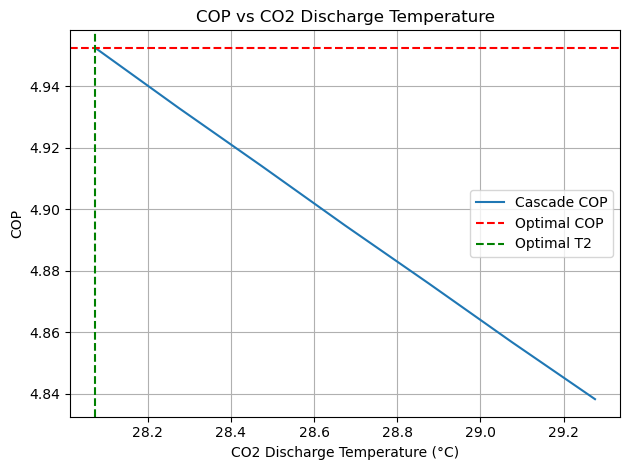

In [25]:
T2_C_plot = [T - 273.15 for T in T2_range]
plt.plot(T2_C_plot, COP_list, label='Cascade COP')
plt.axhline(optimal_COP, color='r', linestyle='--', label='Optimal COP')
if optimal_T2:
    plt.axvline(optimal_T2 - 273.15, color='g', linestyle='--', label='Optimal T2')
plt.xlabel('CO2 Discharge Temperature (°C)')
plt.ylabel('COP')
plt.title('COP vs CO2 Discharge Temperature')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

-----
# Results

### Optimum Temperatures

In [26]:
print('The optimum temperature for the condensation of CO2 {0:1.2f} K.'.format(T3))
print('The optimum temperature for the evaporation of NH4 {0:1.2f} K.'.format(T5))

The optimum temperature for the condensation of CO2 279.34 K.
The optimum temperature for the evaporation of NH4 352.60 K.


### Application of Freezer

A –20 °C freezer is ideally suited for high-performance food preservation, from blast-chilling seafood to long-term storage of meat and ice creams. Operating at such a low temperature ensures rapid solidification of water in food cells, which minimizes ice-crystal growth and preserves texture, flavor, and nutritional value. Moreover, by using a CO₂–ammonia cascade system, the unit leverages natural refrigerants with minimal global warming potential—an advantage that can be highlighted in marketing to appeal to environmentally conscious customers.

### Cooling Capacity

In [27]:
print(f"Cooling Load (QL): {optimal_QL_CO2:.2f} kW")

Cooling Load (QL): 225.08 kW


-----

# Improving the performance

Improving the performance of the unit first requires defining what “performance” means. In this case, performance is defined by the coefficient of performance (COP) of the refrigeration system, given by: COP = Q<sub>L</sub> / W<sub>in</sub>. Maximizing Q<sub>L</sub> alone does not necessarily lead to a higher COP, as the input work W<sub>in</sub> may increase even more. Therefore, to truly optimize performance, we must maximize the ratio Q<sub>L</sub>/W<sub>in</sub>, not just the cooling load itself. To achieve this, we implemented an iterative process that evaluated combinations of CO₂ discharge temperature (T₂) and NH₃ discharge temperature (T₆) across feasible ranges. We included several key constraints to ensure that our optimization process realistically and effectively modeled a cascading refrigeration cycle. Before the process began we set constraints for the minimum temperature in the heat exchanger to ensure realistic heat transfer. We also set bounds for the mass flow rate of NH₃ to make sure it was similar in magnitude to the mass flow rate of CO₂.

The steps were:

1. Sweep through a range of T₂ values (CO₂ discharge temperature). We ensured these values were realistic by bounding the lower end to one degree above the the temperature in the CO2 evaporator and the upper limit to one tenth of a degree lower than the CO₂ critical temperature to ensure realistic compression.
    
    1a.  Calculate the pressure (P2) under isentropic compression and verify that a pressure ratio of at            least was satisfied for the compressor to ensure system stability. We also compared these                  pressures to the critical pressure of CO₂ to make sure that the compression was realistic and              stable.

    1b. Calculate valid enthalpies, work and cooling load for CO₂ cycle.

2. For each feasible T₂, sweep through a range of T₆ values (NH₃ discharge temperature). The range of T6 values was determined iteraively by a process of looping and narrowing the range to find the highest COP. We made sure to never exceed the NH₃ critical temp while never going below a temperature that would not allow heat transfer to the environment. 
    
3. For each feasible (T₂, T₆) pair:

    3a. Verify that a pressure ratio of at least 1.5 was satisfied for the NH₃ compression for stability,      the critical pressure of NH₃ was not exceeded, and that postive work was provided to the NH₃               compressor. Compute the cycle enthalpies, realistic mass flow rate of NH₃ and, energy flows.

    3b. Calculate the work input to the NH₃ compressor and total work input (CO₂ and NH₃ compressors).

    3c. Evaluate COP and check if it is the maximum found so far.

4. Record the optimal T₂ and T₆ values that yield the highest COP.

This approach allowed us to identify the best operating parameters for maximizing system efficiency.

In addition to this approach, we suggest introducing a superheater to further improve COP by reducing irreversibilities in the heat exchange process between the low- and high-temperature cycles. By superheating the CO₂ refrigerant after compression and before it enters the cascade heat exchanger, the superheater raises the temperature of the gas, narrowing the temperature difference between the two refrigerants. This reduces entropy generation and increases the effectiveness of the heat transfer.  Overall, the superheater contributes to higher thermodynamic efficiency by better matching temperatures, thereby reducing input work relative to the cooling effect and ultimately boosting the system’s COP.

----

# Conclusions

In this analysis, we investigated the performance of a CO₂–ammonia cascade refrigeration system to optimize its COP. By systematically sweeping through a range of discharge temperatures for both refrigerants (T₂ for CO₂ and T₆ for NH₃), we evaluated the thermodynamic behavior of the system and determined the conditions under which the COP was maximized. We also suggest using a superheater to similarly improve the performance of the system. 

Our results show that identifying an optimal balance between the cooling load and the total work input is essential for improving efficiency. Additionally, the use of natural refrigerants like CO₂ and ammonia presents a sustainable alternative to high-GWP synthetic refrigerants, supporting the shift toward environmentally responsible refrigeration.

This study provided valuable insights into cascade system design and optimization. Future work could incorporate real-world compressor and heat exchanger efficiencies, dynamic load conditions, or explore alternative fluid pairs for enhanced performance and environmental impact.